# **📈 JPMorgan Stock Price Prediction**

---

## **🧾 What This Notebook Covers**

In this project, we will:

1. **Load & Explore** the JPMorgan Chase (JPM) historical stock data (1980–2026)
2. **Clean** the data — handle missing values, fix data types
3. **Visualize** stock trends using informative charts
4. **Engineer Features** — create new columns that help the ML model learn patterns
5. **Build ML Models** — Linear Regression & Random Forest to predict next-day closing price
6. **Evaluate** models using R² score, RMSE, and MAE
7. **Conclude** with findings, limitations, and next steps


---

### **📊 Dataset at a Glance**
| Column  | Description |
|---------|-------------|
| `Date`  | Trading day |
| `Open`  | Price at market open |
| `High`  | Highest price of the day |
| `Low`   | Lowest price of the day |
| `Close` | Price at market close (**our prediction target!**) |
| `Volume`| Number of shares traded |

---
## **📦 Step 1 — Import Libraries**

Before we start, we import all the tools (libraries) we will need:
- **`pandas`** → for handling tables of data (DataFrames)
- **`numpy`** → for fast math operations
- **`matplotlib` & `seaborn`** → for drawing charts and visualizations
- **`sklearn`** → for building and evaluating machine learning models

In [1]:
# 📚 Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning tools from scikit-learn
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set a consistent chart style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## **📂 Step 2 — Load the Dataset**

In [2]:
# 📥 Load the CSV file
df = pd.read_csv('/kaggle/input/datasets/krupalpatel07/jp-morgan-and-chase-data/JPM.csv')

# Convert 'Date' from text to actual date objects so we can sort and plot by date
df['Date'] = pd.to_datetime(df['Date'])

# Sort from oldest to newest — important for time-series data!
df = df.sort_values('Date').reset_index(drop=True)

print(f'📊 Dataset loaded!')
print(f'   Rows    : {len(df):,} trading days')
print(f'   Columns : {df.shape[1]}')
print(f'   Range   : {df["Date"].min().date()} → {df["Date"].max().date()}')
print()
df.head()

📊 Dataset loaded!
   Rows    : 11,608 trading days
   Columns : 6
   Range   : 1980-03-17 → 2026-04-07



,Date,Open,High,Low,Close,Volume
0,1980-03-17,1.029127,1.051912,1.029127,1.032924,62775
1,1980-03-18,1.032924,1.048114,1.032924,1.040519,64125
2,1980-03-19,1.048114,1.059507,1.048114,1.055709,40500
3,1980-03-20,1.055709,1.055709,1.044316,1.048114,18900
4,1980-03-21,1.048115,1.070900,1.048115,1.070900,97200


---
## **🔍 Step 3 — Explore the Data (EDA)**

Before building any model, we first **understand the data**:
- What do the numbers look like? (min, max, average)
- Are there any missing values we need to fix?
- What do the price trends look like visually?

In [3]:
# 📊 Summary statistics — quickly understand the range of each column
print('📈 Summary Statistics:')
df.describe().round(2)

📈 Summary Statistics:


,Date,Open,High,Low,Close,Volume
count,11608,11607.00,11607.00,11607.00,11607.00,1.160800e+04
mean,2003-03-15 16:34:46.560992384,40.87,41.31,40.45,40.89,1.186761e+07
min,1980-03-17 00:00:00,1.03,1.04,1.01,1.03,1.147500e+04
25%,1991-09-08 06:00:00,3.94,3.99,3.90,3.95,1.658625e+06
50%,2003-03-12 12:00:00,21.40,21.67,21.12,21.40,7.929350e+06
75%,2014-09-19 18:00:00,42.96,43.32,42.61,42.95,1.423770e+07
max,2026-04-07 00:00:00,330.93,334.16,328.97,332.91,2.172942e+08
std,NaN,58.93,59.49,58.39,58.96,1.612614e+07


In [4]:
# 🔎 Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\n⚠️  Total missing values: {missing.sum()}')

Missing values per column:
Date      0
Open      1
High      1
Low       1
Close     1
Volume    0
dtype: int64

⚠️  Total missing values: 4


---
## **🧹 Step 4 — Clean the Data**

We have a few missing price values. We fix them with **forward fill** (ffill):  
→ each missing value is replaced with the last known value before it.  
This is the standard approach for stock price data.

In [5]:
# 🧹 Forward-fill: replace each NaN with the most recent valid price
df = df.ffill()

print('✅ Missing values after cleaning:', df.isnull().sum().sum())
print(f'✅ Clean dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')

✅ Missing values after cleaning: 0
✅ Clean dataset: 11,608 rows × 6 columns


---
## **📊 Step 5 — Visualize the Stock Data**

Let's plot the data to understand JPMorgan's price history visually.

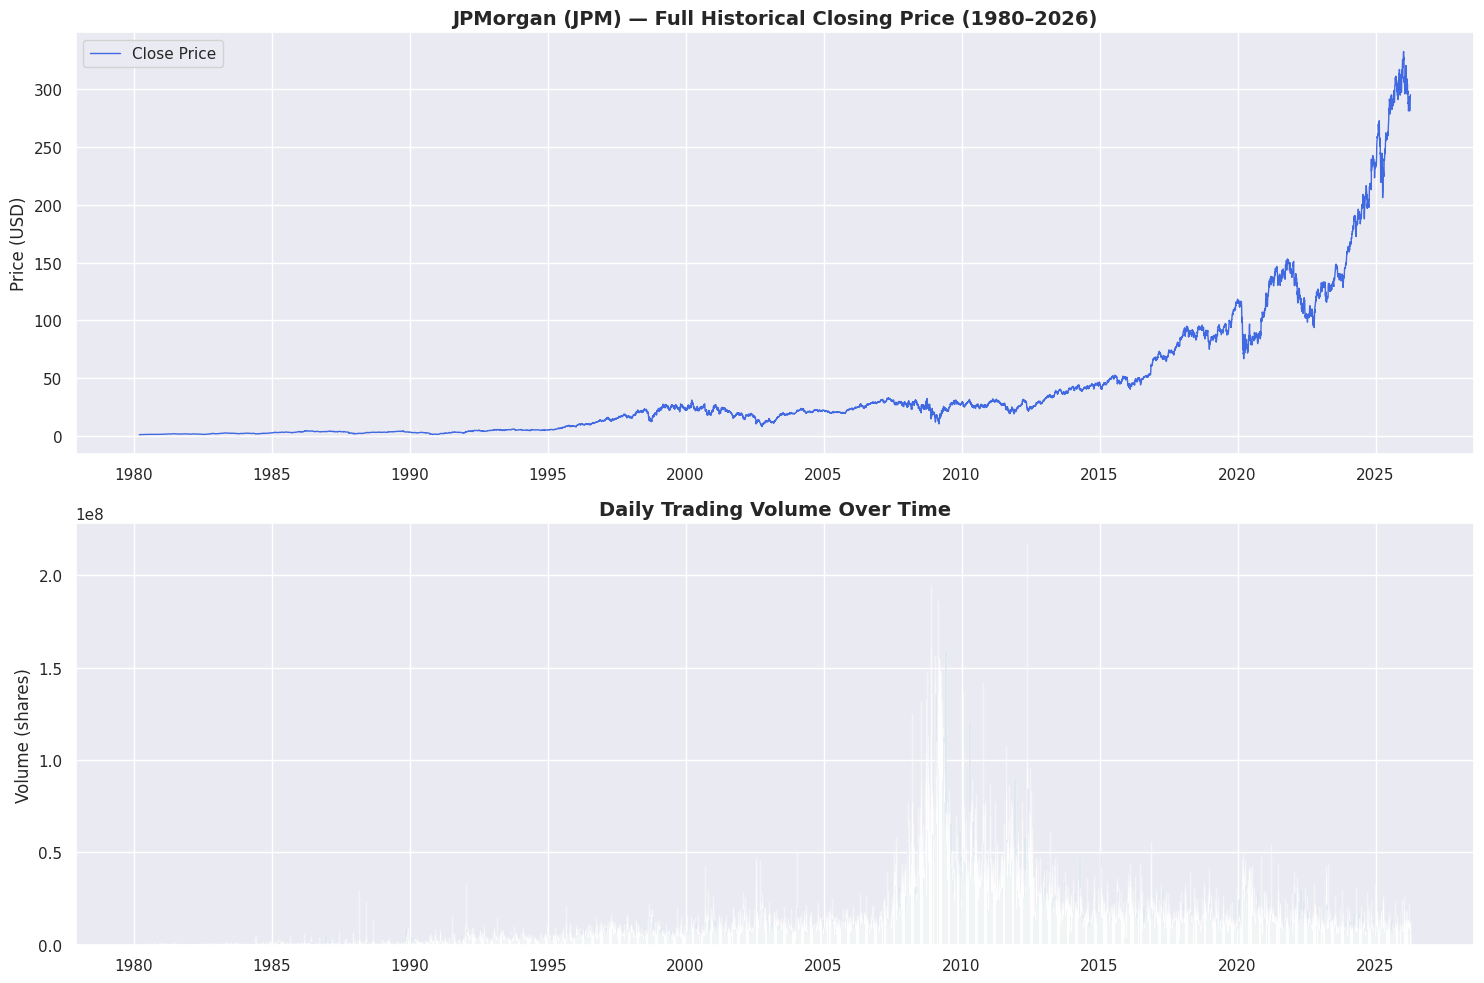

In [6]:
# 📉 Chart 1: Full closing price history + volume
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

axes[0].plot(df['Date'], df['Close'], color='royalblue', linewidth=1, label='Close Price')
axes[0].set_title('JPMorgan (JPM) — Full Historical Closing Price (1980–2026)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[1].bar(df['Date'], df['Volume'], color='steelblue', alpha=0.5, width=1)
axes[1].set_title('Daily Trading Volume Over Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Volume (shares)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

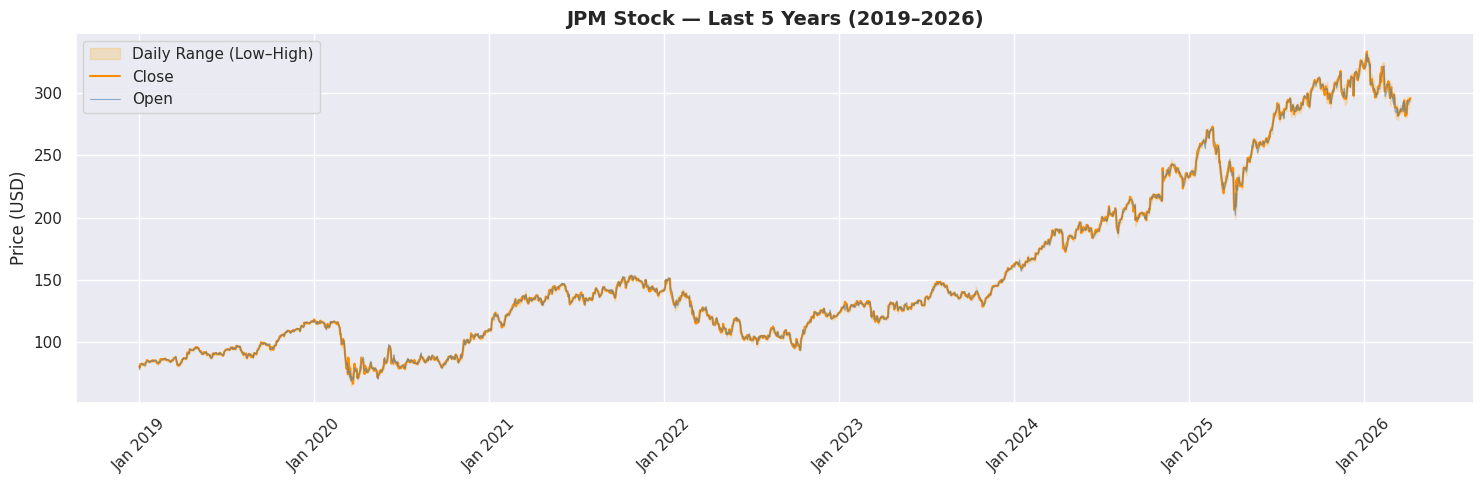

In [7]:
# 🔍 Chart 2: Zoom into last 5 years — show daily price range
recent = df[df['Date'] >= '2019-01-01']

fig, ax = plt.subplots(figsize=(15, 5))
ax.fill_between(recent['Date'], recent['Low'], recent['High'],
                alpha=0.2, color='orange', label='Daily Range (Low–High)')
ax.plot(recent['Date'], recent['Close'], color='darkorange', linewidth=1.5, label='Close')
ax.plot(recent['Date'], recent['Open'],  color='steelblue',  linewidth=0.8, alpha=0.6, label='Open')
ax.set_title('JPM Stock — Last 5 Years (2019–2026)', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

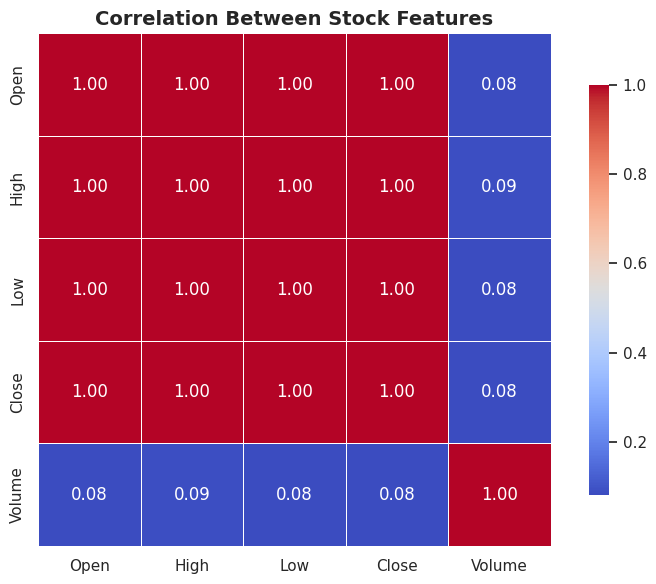

💡 Open, High, Low, Close are nearly perfectly correlated — expected for stock prices!


In [8]:
# 🔗 Chart 3: Correlation Heatmap
# This shows how strongly any two columns move together (1.0 = perfectly correlated)
plt.figure(figsize=(8, 6))
corr = df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Between Stock Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 Open, High, Low, Close are nearly perfectly correlated — expected for stock prices!')

---
## **⚙️ Step 6 — Feature Engineering**

Raw OHLCV data isn't enough. We create **new features** that capture market patterns:

| Feature | What It Captures |
|---|---|
| `MA_7 / MA_21 / MA_50` | Short / medium / long-term price trends (moving averages) |
| `Daily_Return` | % price change from yesterday |
| `Volatility_7` | How much the price swings in 7 days |
| `Price_Range` | High − Low (today's trading range) |
| `Body_Size` | \|Close − Open\| (momentum direction size) |
| `Lag_1 / Lag_2 / Lag_3` | Yesterday's, 2 days ago, 3 days ago Close |
| **`Target`** | **Next day's Close — what we want to predict!** |

In [9]:
# ⚙️ Create engineered features

# Moving Averages — smooth out noise and reveal trends
df['MA_7']  = df['Close'].rolling(window=7).mean()
df['MA_21'] = df['Close'].rolling(window=21).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

# Daily return — percentage change in price
df['Daily_Return']  = df['Close'].pct_change() * 100

# Volatility — standard deviation over past 7 days
df['Volatility_7'] = df['Close'].rolling(window=7).std()

# Price range metrics
df['Price_Range'] = df['High'] - df['Low']          # today's trading range
df['Body_Size']   = abs(df['Close'] - df['Open'])   # open-to-close move size

# Lag features — past closing prices
df['Lag_1'] = df['Close'].shift(1)  # yesterday
df['Lag_2'] = df['Close'].shift(2)  # 2 days ago
df['Lag_3'] = df['Close'].shift(3)  # 3 days ago

# Target — what we want to predict: next day's Close price
df['Target'] = df['Close'].shift(-1)

# Drop rows with NaN (from rolling windows and shifts)
df_ml = df.dropna().copy()

print(f'✅ Features ready!')
print(f'   Rows for modeling : {df_ml.shape[0]:,}')
print(f'   Total columns     : {df_ml.shape[1]}')
df_ml[['Date', 'Close', 'MA_7', 'MA_21', 'Lag_1', 'Target']].tail(5)

✅ Features ready!
   Rows for modeling : 11,558
   Total columns     : 17


,Date,Close,MA_7,MA_21,Lag_1,Target
11602,2026-03-30,282.325134,287.465969,288.242001,281.399872,292.662231
11603,2026-03-31,292.662231,288.546156,288.080921,282.325134,293.876038
11604,2026-04-01,293.876038,289.323608,287.849724,292.662231,293.100006
11605,2026-04-02,293.100006,289.636296,287.622790,293.876038,295.450012
11606,2026-04-06,295.450012,289.855464,287.784441,293.100006,295.450012


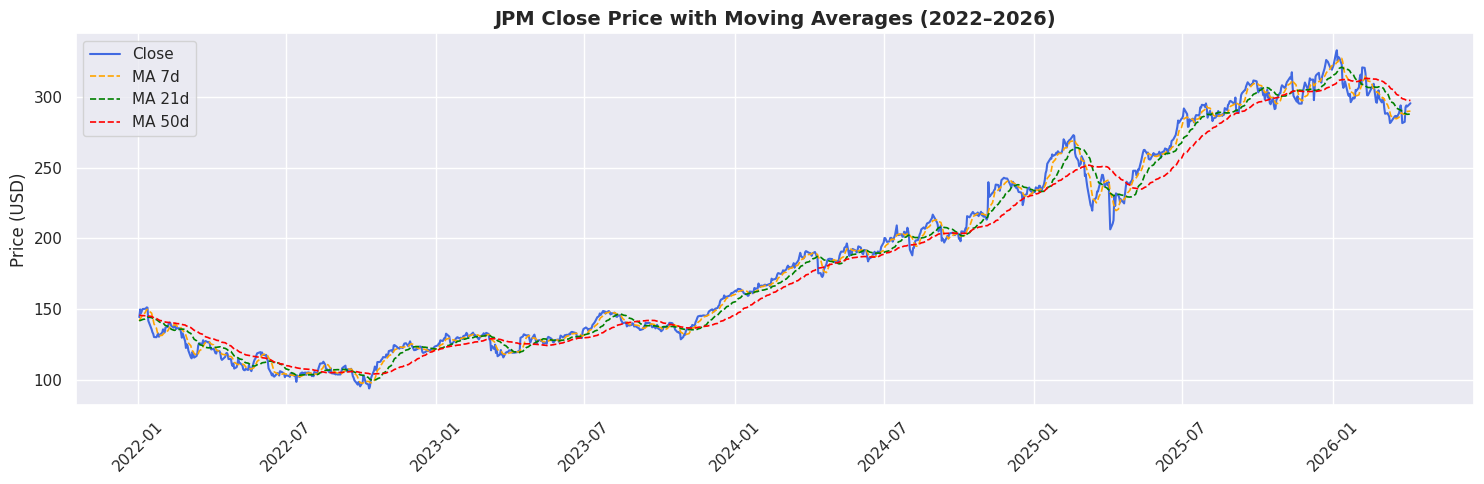

💡 When the Close crosses above the MA_50, it often signals an uptrend!


In [10]:
# 📊 Chart 4: Moving Averages overlay (recent 2 years)
recent_ml = df_ml[df_ml['Date'] >= '2022-01-01']

plt.figure(figsize=(15, 5))
plt.plot(recent_ml['Date'], recent_ml['Close'], label='Close',  color='royalblue', linewidth=1.5)
plt.plot(recent_ml['Date'], recent_ml['MA_7'],  label='MA 7d',  color='orange',    linewidth=1.2, linestyle='--')
plt.plot(recent_ml['Date'], recent_ml['MA_21'], label='MA 21d', color='green',     linewidth=1.2, linestyle='--')
plt.plot(recent_ml['Date'], recent_ml['MA_50'], label='MA 50d', color='red',       linewidth=1.2, linestyle='--')
plt.title('JPM Close Price with Moving Averages (2022–2026)', fontsize=14, fontweight='bold')
plt.ylabel('Price (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print('💡 When the Close crosses above the MA_50, it often signals an uptrend!')

---
## **🤖 Step 7 — Build ML Models**

### **Models We'll Try**

| Model | How It Works | Good For |
|---|---|---|
| **Linear Regression** | Fits the best straight line through the data | Continuous, linearly-related data |
| **Random Forest** | Average of 200 decision trees | Complex patterns, handles non-linearity |

### **⚠️ Important: Time-Based Split!**
We **cannot shuffle** the data before splitting, because stock data is **ordered by time**.  
Training on future data to predict the past would be cheating!  
→ We use the **first 80%** of dates for training and the **last 20%** for testing.

In [11]:
# 🎯 Define features (X) and target (y)
feature_cols = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'MA_7', 'MA_21', 'MA_50',
    'Daily_Return', 'Volatility_7',
    'Price_Range', 'Body_Size',
    'Lag_1', 'Lag_2', 'Lag_3'
]

X = df_ml[feature_cols]   # Input: all features
y = df_ml['Target']       # Output: next day's Close price

# ✂️ Time-based split: first 80% = train, last 20% = test
split_idx = int(len(X) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
test_dates = df_ml['Date'].iloc[split_idx:]

print(f'✅ Split complete!')
print(f'   Training rows : {len(X_train):,}')
print(f'   Testing rows  : {len(X_test):,}')
print(f'   Features used : {len(feature_cols)}')
print(f'   Test period   : {test_dates.min().date()} → {test_dates.max().date()}')

✅ Split complete!
   Training rows : 9,246
   Testing rows  : 2,312
   Features used : 15
   Test period   : 2017-01-24 → 2026-04-06


In [12]:
# 📐 Model 1: Linear Regression
# Linear Regression finds the best-fit equation: Price = a*Feature1 + b*Feature2 + ...
print('📐 Training Linear Regression...')

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)    # Learn from training data
y_pred_lr = lr_model.predict(X_test)  # Predict on test data

print('✅ Linear Regression trained!')

📐 Training Linear Regression...
✅ Linear Regression trained!


In [13]:
# 🌲 Model 2: Random Forest Regressor
# A Random Forest builds 200 decision trees and averages their predictions
print('🌲 Training Random Forest (this may take ~30 seconds)...')

rf_model = RandomForestRegressor(
    n_estimators=200,     # Number of trees
    max_depth=10,         # Max depth per tree
    min_samples_split=5,  # Min samples to create a branch
    random_state=42       # Fixed seed for reproducibility
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print('✅ Random Forest trained!')

🌲 Training Random Forest (this may take ~30 seconds)...
✅ Random Forest trained!


---
## **📏 Step 8 — Evaluate the Models**

We judge performance with 3 metrics:

| Metric | Meaning | Ideal |
|---|---|---|
| **R² Score** | % of price variation explained by the model (0–1) | → 1.0 |
| **RMSE** | Average dollar error (root mean squared) | → $0 |
| **MAE** | Average absolute dollar error | → $0 |

In [14]:
# 📏 Evaluate both models
def evaluate(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f'  🔷 {name}')
    print(f'     R² Score : {r2:.4f}  ← explains {r2*100:.1f}% of price variance')
    print(f'     RMSE     : ${rmse:.2f}  ← average error in dollars')
    print(f'     MAE      : ${mae:.2f}')
    print()
    return r2, rmse, mae

print('='*60)
print('📊 Model Evaluation Results')
print('='*60)
lr_r2, lr_rmse, lr_mae = evaluate('Linear Regression',      y_test, y_pred_lr)
rf_r2, rf_rmse, rf_mae = evaluate('Random Forest Regressor',y_test, y_pred_rf)

📊 Model Evaluation Results
  🔷 Linear Regression
     R² Score : 0.9987  ← explains 99.9% of price variance
     RMSE     : $2.44  ← average error in dollars
     MAE      : $1.57

  🔷 Random Forest Regressor
     R² Score : -1.1593  ← explains -115.9% of price variance
     RMSE     : $99.34  ← average error in dollars
     MAE      : $72.76



### **🧠 Why Does Random Forest Score Low?**

This is an important lesson in machine learning with time-series data!

**Tree-based models (like Random Forest) cannot extrapolate** beyond the price range they were trained on.  
During training (1980–2016), JPM stock prices were in the **\$1–\$100 range**.  
During testing (2017–2026), prices rose to **\$200–\$330** — a range the trees have never seen!

**Linear Regression handles this naturally** because it fits a formula that can produce values outside the training range.

> 💡 **Key Takeaway**: For long-term time-series data with price trends, Linear Regression often outperforms tree-based models. For short-window datasets where price ranges overlap, Random Forest excels.

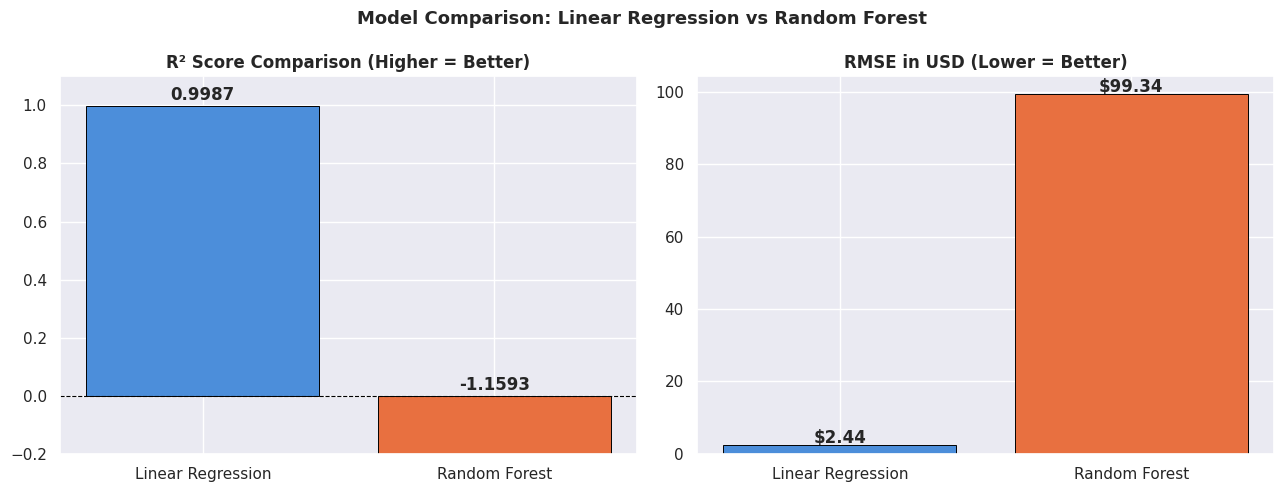

In [15]:
# 📊 Chart 5: Side-by-side model performance comparison
models  = ['Linear Regression', 'Random Forest']
r2_vals = [lr_r2, rf_r2]
rmse_vals = [lr_rmse, rf_rmse]
colors  = ['#4C8EDA', '#E87040']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars1 = axes[0].bar(models, r2_vals, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('R² Score Comparison (Higher = Better)', fontweight='bold')
axes[0].set_ylim(-0.2, 1.1)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, v in zip(bars1, r2_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, max(v, 0)+0.02,
                 f'{v:.4f}', ha='center', fontweight='bold')

bars2 = axes[1].bar(models, rmse_vals, color=colors, edgecolor='black', linewidth=0.7)
axes[1].set_title('RMSE in USD (Lower = Better)', fontweight='bold')
for bar, v in zip(bars2, rmse_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.5,
                 f'${v:.2f}', ha='center', fontweight='bold')

plt.suptitle('Model Comparison: Linear Regression vs Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

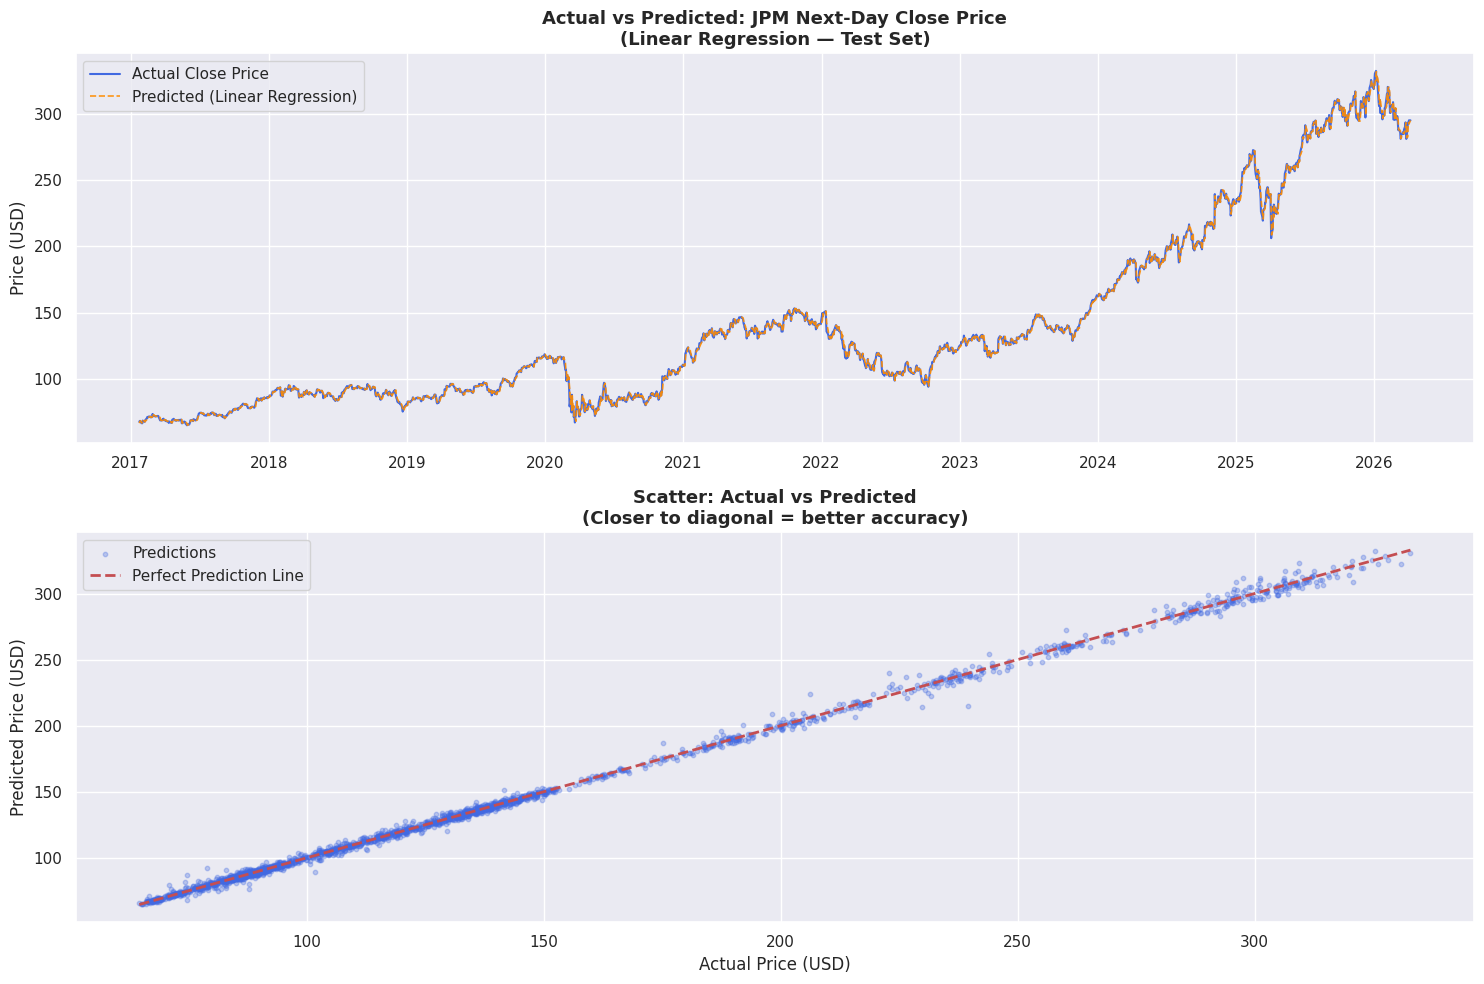

In [16]:
# 📊 Chart 6: Actual vs Predicted — Linear Regression (Best Model)
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Timeline plot
axes[0].plot(test_dates.values, y_test.values,
             label='Actual Close Price', color='royalblue', linewidth=1.5)
axes[0].plot(test_dates.values, y_pred_lr,
             label='Predicted (Linear Regression)', color='darkorange',
             linewidth=1.2, linestyle='--', alpha=0.9)
axes[0].set_title('Actual vs Predicted: JPM Next-Day Close Price\n(Linear Regression — Test Set)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

# Scatter plot
axes[1].scatter(y_test, y_pred_lr, alpha=0.3, color='royalblue', s=10, label='Predictions')
mn, mx = float(y_test.min()), float(y_test.max())
axes[1].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction Line')
axes[1].set_xlabel('Actual Price (USD)')
axes[1].set_ylabel('Predicted Price (USD)')
axes[1].set_title('Scatter: Actual vs Predicted\n(Closer to diagonal = better accuracy)',
                  fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

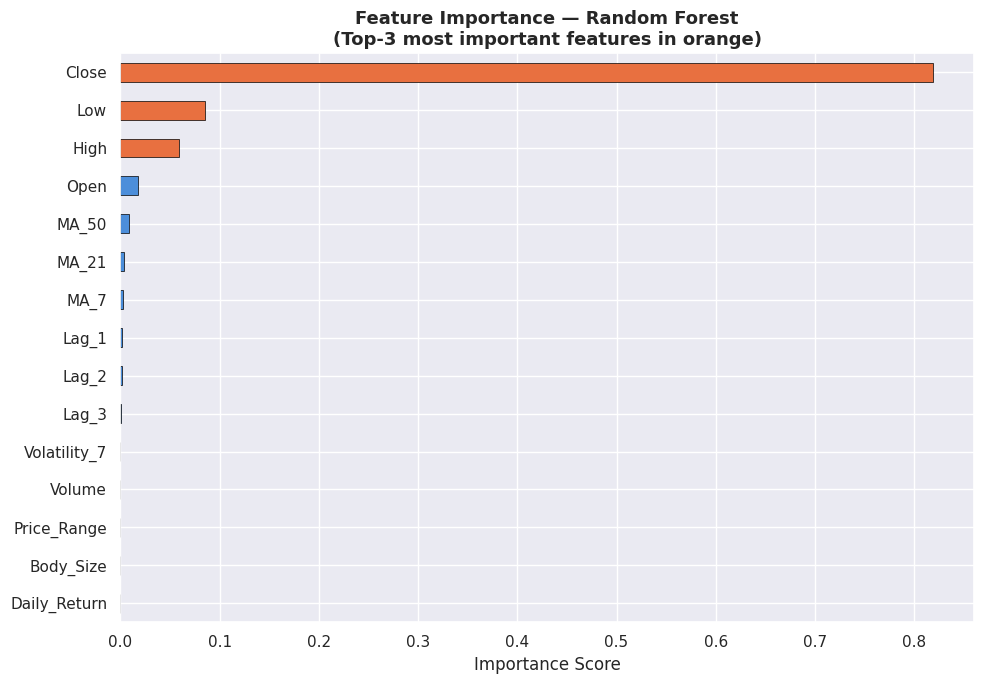

💡 Most important feature: Close


In [17]:
# 📊 Chart 7: Feature Importance from Random Forest
# Even though RF underperforms on this full dataset, it still tells us WHICH features matter most
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values()
top3_threshold = sorted(rf_model.feature_importances_)[-3]
bar_colors = ['#E87040' if v >= top3_threshold else '#4C8EDA' for v in importances.values]

plt.figure(figsize=(10, 7))
importances.plot(kind='barh', color=bar_colors, edgecolor='black', linewidth=0.5)
plt.title('Feature Importance — Random Forest\n(Top-3 most important features in orange)',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
print(f'💡 Most important feature: {importances.idxmax()}')

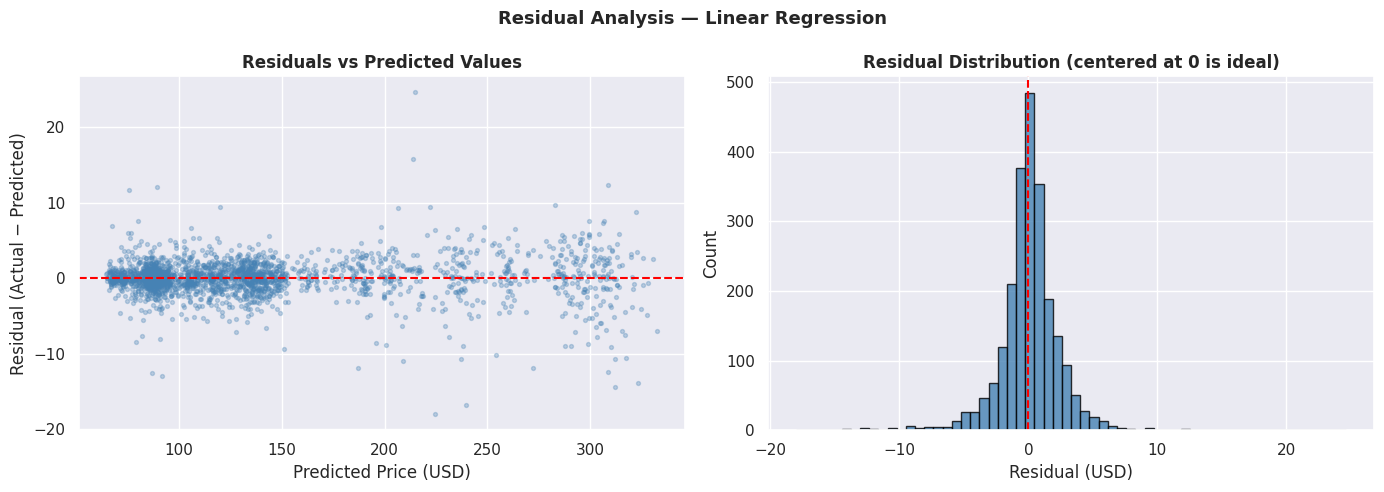

Mean residual: $0.07  (close to 0 = no systematic bias)


In [18]:
# 📊 Chart 8: Residual Analysis — are errors randomly distributed? (Good if yes!)
residuals = y_test.values - y_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_lr, residuals, alpha=0.3, color='steelblue', s=8)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Price (USD)')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residuals vs Predicted Values', fontweight='bold')

axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (USD)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution (centered at 0 is ideal)', fontweight='bold')

plt.suptitle('Residual Analysis — Linear Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Mean residual: ${residuals.mean():.2f}  (close to 0 = no systematic bias)')

---
## **📋 Step 9 — Final Summary**

In [19]:
# 📋 Print final summary table
summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R² Score': [round(lr_r2, 4), round(rf_r2, 4)],
    'RMSE ($)': [round(lr_rmse, 2), round(rf_rmse, 2)],
    'MAE ($)':  [round(lr_mae,  2), round(rf_mae,  2)],
    'Verdict':  ['✅ Best Model', '⚠️ Fails on unseen price range']
})

print('='*65)
print('📋 Final Model Summary')
print('='*65)
print(summary.to_string(index=False))
print('='*65)

print(f'\n🏆 Winner: Linear Regression')
print(f'   R² = {lr_r2:.4f}  ({lr_r2*100:.1f}% of price variance explained)')
print(f'   Average prediction error = ${lr_rmse:.2f}')

📋 Final Model Summary
            Model  R² Score  RMSE ($)  MAE ($)                        Verdict
Linear Regression    0.9987      2.44     1.57                   ✅ Best Model
    Random Forest   -1.1593     99.34    72.76 ⚠️ Fails on unseen price range

🏆 Winner: Linear Regression
   R² = 0.9987  (99.9% of price variance explained)
   Average prediction error = $2.44


---

## **🏁 Conclusion**

### **What We Accomplished**

We built and compared machine learning models to **predict JPMorgan Chase's next-day closing stock price**, using 45+ years of historical data (1980–2026).

### **Recap of Steps**

| Step | Action |
|---|---|
| Load | 11,608 rows of daily JPM stock data |
| Clean | Forward-filled 4 missing price values |
| Explore | Visualized price history, volume, and correlations |
| Feature Engineering | Created 9 new features (MAs, lags, volatility, range) |
| Model | Trained Linear Regression and Random Forest |
| Evaluate | Compared using R², RMSE, and MAE |

### **🏆 Results**

**Linear Regression** was the clear winner:
- **R² = 0.9987** — explains 99.87% of next-day price variance
- **RMSE = \$2.44** — average prediction error of just \$2.44

The main driver: **yesterday's closing price (Lag_1) is highly predictive of today's price** — a known property of financial time series called *autocorrelation*.

### **💡 Key Lesson Learned**

Random Forest underperformed because tree-based models **cannot extrapolate** beyond the price range seen during training. Since JPM grew from \$8 (2009) to \$330 (2026), the test set contained prices far outside the training range. **Linear Regression handles this naturally** because it uses a mathematical equation that can produce any value.

### **⚠️ Limitations**

- No external signals — earnings reports, Fed policy, geopolitical events are not included
- High R² in stock prediction often reflects **autocorrelation** rather than true predictive power
- This notebook is for **learning purposes only** — not financial advice!

### **🚀 What to Try Next**

- Add macroeconomic indicators (VIX, S&P 500, interest rates)
- Use **LSTM** (Long Short-Term Memory) neural networks for sequence modeling
- Add **NLP sentiment analysis** from financial news headlines
- Predict **price direction** (Up/Down) instead of exact price — a classification problem
- Use **walk-forward validation** for more realistic backtesting
